In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print('Shape:', df.shape)
print()
print('Proporsi kelas Churn:')
print(df['Churn'].value_counts(normalize=True).round(4))
df.head()

Shape: (7043, 21)

Proporsi kelas Churn:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
from sklearn.model_selection import train_test_split

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df = df.drop(columns=['customerID'])

y = (df['Churn'] == 'Yes').astype(int)

X = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)
print('Jumlah fitur setelah encoding:', X.shape[1])

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_tr.shape, '| Test:', X_te.shape)
print('Proporsi churn di train:', y_tr.mean().round(4),
      '| di test:', y_te.mean().round(4))

Jumlah fitur setelah encoding: 30
Train: (5634, 30) | Test: (1409, 30)
Proporsi churn di train: 0.2654 | di test: 0.2654


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42)

rf.fit(X_tr, y_tr)
print('Model selesai dilatih:', rf)

Model selesai dilatih: RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)


              precision    recall  f1-score   support

 Tidak Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8246


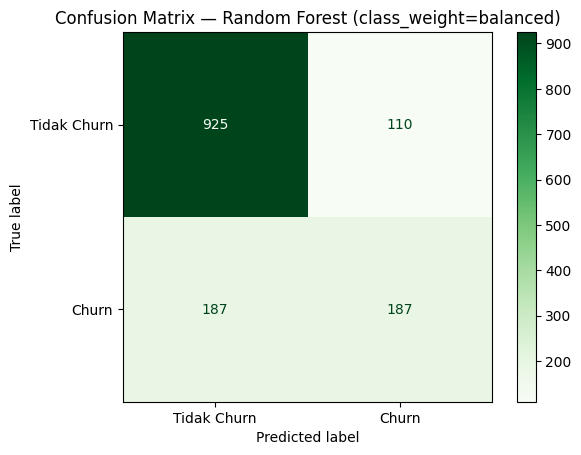

In [12]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)

pred  = rf.predict(X_te)
proba = rf.predict_proba(X_te)[:, 1]

print(classification_report(y_te, pred, target_names=['Tidak Churn', 'Churn']))
print('ROC-AUC:', roc_auc_score(y_te, proba).round(4))

ConfusionMatrixDisplay(confusion_matrix(y_te, pred),
                       display_labels=['Tidak Churn', 'Churn']).plot(cmap='Greens')
plt.title('Confusion Matrix — Random Forest (class_weight=balanced)')
plt.show()

In [14]:
hasil_proba = X_te.copy()
hasil_proba['proba_churn'] = proba
hasil_proba['aktual'] = y_te.values

top_risiko = hasil_proba.sort_values('proba_churn', ascending=False)
top_risiko[['tenure', 'MonthlyCharges', 'TotalCharges',
            'proba_churn', 'aktual']].head(10)

,tenure,MonthlyCharges,TotalCharges,proba_churn,aktual
1731,1,69.60,69.60,1.000000,1
2194,1,79.50,79.50,0.993333,1
809,1,69.55,69.55,0.990000,1
6623,1,76.45,76.45,0.990000,1
1739,1,69.90,69.90,0.986667,1
2927,1,69.90,69.90,0.986667,0
3346,2,84.05,186.05,0.970000,0
1144,1,35.55,35.55,0.963333,1
4585,1,85.05,85.05,0.960000,1
2729,2,85.70,169.80,0.950000,1


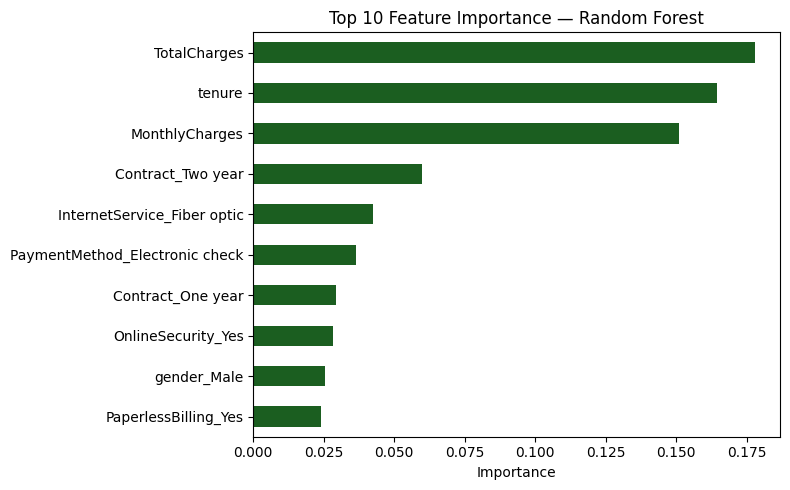

In [15]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10)
plt.figure(figsize=(8, 5))
imp.plot(kind='barh', color='#1B5E20')
plt.title('Top 10 Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Kesimpulan

1. predict_proba memberikan tiap pelanggan skor 0 sampai 1. Pelanggan dengan skor mendekati 1 adalah pelanggan beresiko (churn)
2. Jadi pelanggan churn karena ternyata pelanggan baru, kontrak bulanan, dan tagihan mahal.
3. Pelanggan dengan tenure pendek, kontrak bulanan, dan tagihan tinggi paling rawan churn
